# **1. 서울 자전거 공유 수요 데이터셋**
서울시의 공공자전거 대여 서비스인 ‘따릉이’의 대여 수요를 예측하는 문제에 사용되는 데이터셋입니다. 특정 시간대와 날씨, 요일, 공휴일 여부, 기온, 습도 등 다양한 데이터를 활용하여 자전거 대여 수요를 예측합니다.

# **2. 데이터셋 컬럼**

```
Date : 연월일
Rented Bike count - 매 시간마다 대여한 자전거 수
Hour - 하루 중 시간
Temperature - 온도
Humidity - 습도 %
Windspeed - 풍속 m/s
Visibility - 가시거리 m
Dew point temperature - 이슬점 온도
Solar radiation - 태양 복사 MJ/m2
Rainfall - 강우량 mm
Snowfall - 적설량 cm
Seasons - 겨울, 봄, 여름, 가을
Holiday - 휴일/휴일 없음
Functional Day - 운영되지 않았던 날, 정상적으로 운영된 날
```

In [11]:
import pandas as pd
from pathlib import Path

### ※ CP949
- Microsoft Windows의 한국어 문자 인코딩입니다.
- EUC-KR을 확장한 형태로, 더 많은 한국어 문자(한자, 확장 문자 등)를 지원합니다.
- 주로 Windows 환경에서 저장된 한글 파일에서 사용됩니다.

In [12]:
DATA_PATH = Path('./SeoulBikeData.csv')
bike_raw = pd.read_csv(DATA_PATH, encoding='cp949')
bike_raw;

# **3. 데이터 전처리 및 탐색적 데이터 분석 (EDA)**
Exploratory Data Analysis의 약자로 데이터를 본격적으로 모델링하거나 가설을 검증하기 전에 데이터의 구조, 특성, 패턴, 이상치, 변수 간의 관계를 이해하는 과정

### 1. EDA의 목적
- 데이터의 전체적인 구조 파악
- 결측치 확인
- 이상치 탐색
- 변수의 분포 확인
- 변수 간 관계 분석
- 데이터 품질 문제 발견
- 모델링 전에 전처리 방향 결정
- 새로운 가설 생성

### 2. EDA의 전체 과정
1. 데이터 불러오기
2. 데이터 구조 확인
3. 기초 통계 확인
4. 결측치 확인
5. 이상치 확인
6. 단변량 분석
7. 다변량 분석
8. 시각화
9. 인사이트 도출
10. 전처리 방향 결정

In [13]:
bike_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(캜)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(캜)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [14]:
bike_raw.describe()

,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [15]:
bike_raw.describe(include='str')

,Date,Seasons,Holiday,Functioning Day
count,8760,8760,8760,8760
unique,365,4,2,2
top,01/12/2017,Spring,No Holiday,Yes
freq,24,2208,8328,8465


In [16]:
bike_raw.describe(include='all')

,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760
unique,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,01/12/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,NaN,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,NaN,NaN,NaN
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,NaN,NaN,NaN
min,NaN,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,NaN,NaN,NaN


In [17]:
bike_df = bike_raw.copy()

In [18]:
bike_df.columns = [
    'Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity',
    'Wind speed', 'Visibility', 'Dew point temperature',
    'Solar Radiation', 'Rainfall', 'Snowfall', 'Seasons',
    'Holiday', 'Functioning Day'
]

bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [19]:
quality_report = pd.DataFrame({
    'missing_count': bike_df.isna().sum(),
    'missing_ratio': bike_df.isna().mean(),
    'nunique': bike_df.nunique()
})

print(quality_report)

                       missing_count  missing_ratio  nunique
Date                               0            0.0      365
Rented Bike Count                  0            0.0     2166
Hour                               0            0.0       24
Temperature                        0            0.0      546
Humidity                           0            0.0       90
Wind speed                         0            0.0       65
Visibility                         0            0.0     1789
Dew point temperature              0            0.0      556
Solar Radiation                    0            0.0      345
Rainfall                           0            0.0       61
Snowfall                           0            0.0       51
Seasons                            0            0.0        4
Holiday                            0            0.0        2
Functioning Day                    0            0.0        2


In [20]:
# 중복 행 개수
bike_df.duplicated().sum()

np.int64(0)

### 3. 날짜 처리와 피처 엔지니어링
- Date는 문자열 그대로 모델에 넣을 수 없음
- 날짜를 여러 의미있는 변수로 나눔
    - year, month, day, dayofweek, is_weekend
    - hour_sin, hour_cos: 23시와 0시가 가깝다는 것을 모델에 알려주는 주기형 인코딩
    - month_sin, month_cos: 12월과 1월이 가깝다는 것을 모델에 알려주는 주기형 인코딩

In [21]:
# 01/12/2017 > 일/월/년	
bike_df['Date'] = pd.to_datetime(bike_df['Date'], format='%d/%m/%Y')
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [22]:
bike_df['year'] = bike_df['Date'].dt.year
bike_df['month'] = bike_df['Date'].dt.month
bike_df['day'] = bike_df['Date'].dt.day
bike_df['dayofweek'] = bike_df['Date'].dt.dayofweek
bike_df['is_weekend'] = bike_df['dayofweek'].isin([5, 6]).astype(int)
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,year,month,day,dayofweek,is_weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0


### 시간과 월은 반복되는 순환 구조
- 머신러닝의 이해: 0 < 1 < 2 < ... < 23
- 사람: 23 < 0 < 1 .. (순환)
- np.pi * 2 * bike_df['Hour'] / 24 : 시간을 각도로 변환
- sin: 원에서 y좌표를 의미 (0, 1) (1, 0), (0, -1), (-1, 0) / 1 > 0 > -1 > 0 > 1 ...
- cos: 원에서 x좌표를 의미 (0, 1) (1, 0), (0, -1), (-1, 0) / 1 > 0 > -1 > 0 > 1 ...
> sin만 사용하면 같은 sin값을 가질 수 있는 시간이 생김. cos까지 사용하면 원 위치가 완벽하게 결정

```
시간    각도    sin     cos
0시     0      0       1
6시     90     1       0
12시    180    0       -1
18시    270    -1      0
24시    360    0       1
```


In [23]:
import numpy as np

In [24]:
# 시간
bike_df['hour_sin'] = np.sin(2 * np.pi * bike_df['Hour'] / 24)
bike_df['hour_cos'] = np.cos(2 * np.pi * bike_df['Hour'] / 24)

# 월
bike_df['month_sin'] = np.sin(2 * np.pi * bike_df['month'] / 12)
bike_df['month_cos'] = np.cos(2 * np.pi * bike_df['month'] / 12)

bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,...,Functioning Day,year,month,day,dayofweek,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,0,0.000000,1.000000,-2.449294e-16,1.0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,0,0.258819,0.965926,-2.449294e-16,1.0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,Yes,2017,12,1,4,0,0.500000,0.866025,-2.449294e-16,1.0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,Yes,2017,12,1,4,0,0.707107,0.707107,-2.449294e-16,1.0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,Yes,2017,12,1,4,0,0.866025,0.500000,-2.449294e-16,1.0


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
plt.rcParams['font.family'] = 'Malgun Gothic'

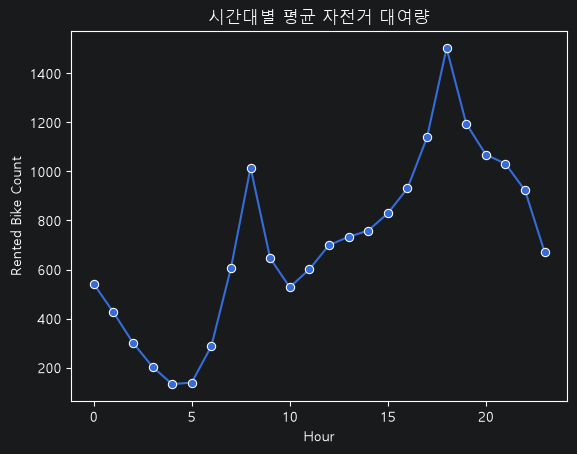

In [27]:
# 시간대별 평균 대여량
hourly_demand = bike_df.groupby('Hour')['Rented Bike Count'].mean().reset_index()
sns.lineplot(data=hourly_demand, x='Hour', y='Rented Bike Count', marker='o')
plt.title('시간대별 평균 자전거 대여량')
plt.show()

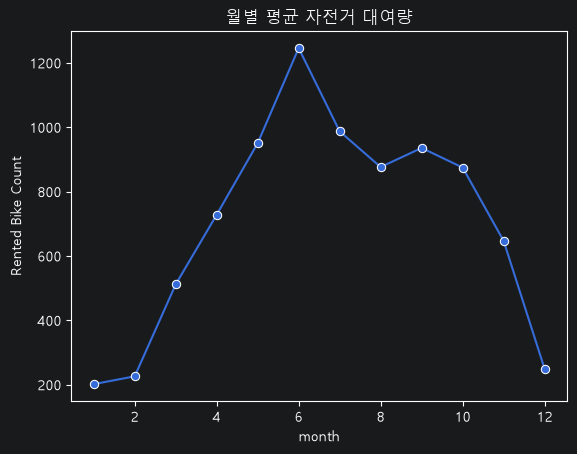

In [28]:
# 월별 평균 대여량
monthly_demand = bike_df.groupby('month')['Rented Bike Count'].mean().reset_index()
sns.lineplot(data=monthly_demand, x='month', y='Rented Bike Count', marker='o')
plt.title('월별 평균 자전거 대여량')
plt.show()

### Seaborn의 barplot
- 막대: 막대의 높이는 기본적으로 평균. x축(또는 y축)에 있는 각 범주(category)별로 y값(수치형)의 평균을 계산해서 그 평균을 막대 높이로 그림. 막대가 높다는 것은 그 범주의 평균이 높다는 뜻
- 막대끼리 비교할 때는 "차이의 크기"를 봄
    - A 막대가 B보다 높다 > A의 평균이 더 크다
    - 막대 차이가 크다 > 집단 간 평균 차이가 크다
    - 비슷하다 > 큰 차이가 없다(평균 관점) : 평균이 비슷해도 데이터가 다를 수 있음
- 에러바: 평균이 얼마나 믿을 만한지 또는 흔들리는지를 표현하는 바. 데이터를 기반으로 유사한 100가지의 케이스에서 95개 이상은 해당 범위에서 결과를 얻음을 의미 > 평균/중앙값/최빈값 등의 다른 값들을 함께 고려한 신뢰성 있는 수치

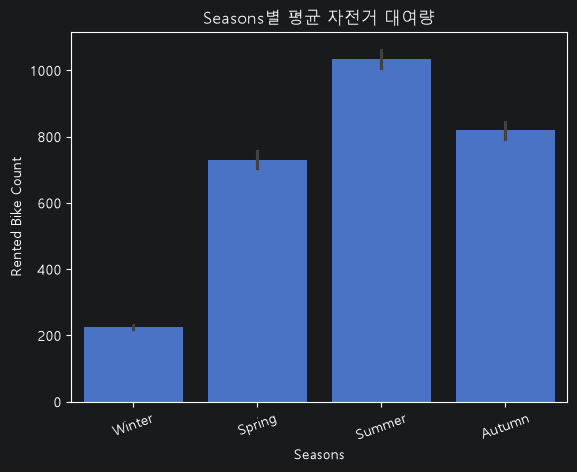

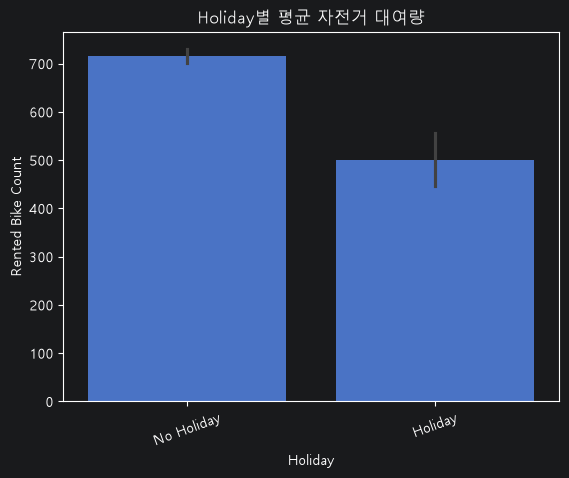

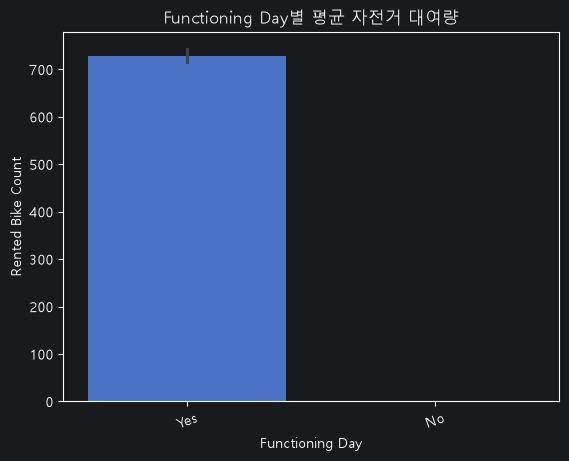

In [29]:
# 계절/공휴일/운영일별 평균 대여량
for col in ['Seasons', 'Holiday', 'Functioning Day']:
    sns.barplot(data=bike_df, x=col, y='Rented Bike Count')
    plt.title(f'{col}별 평균 자전거 대여량')
    plt.xticks(rotation=20)
    plt.show()

In [30]:
plt.rcParams['axes.unicode_minus'] = False

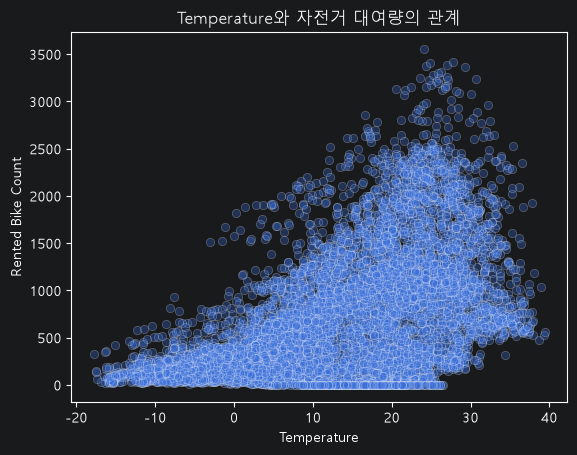

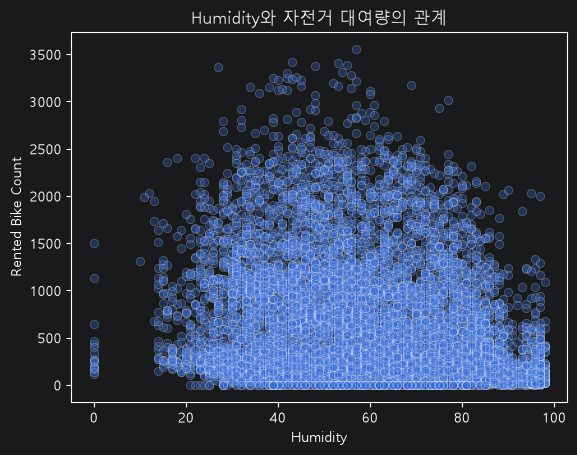

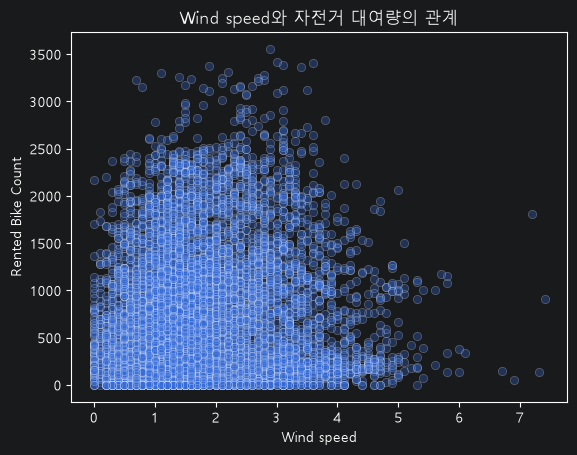

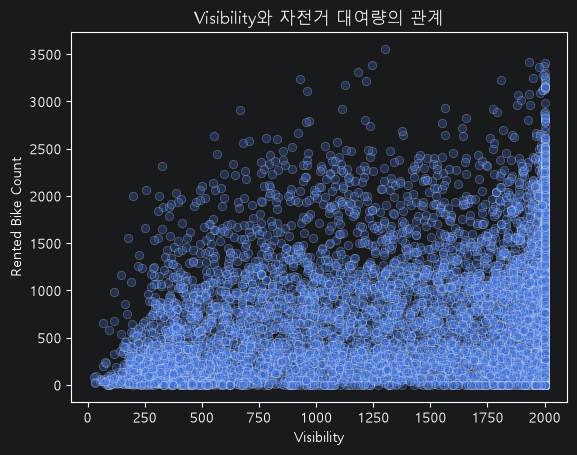

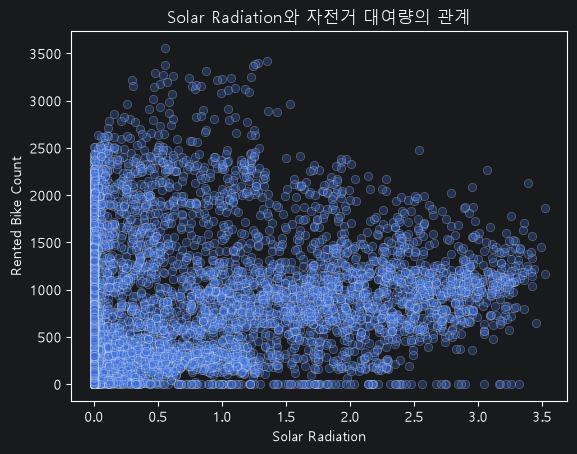

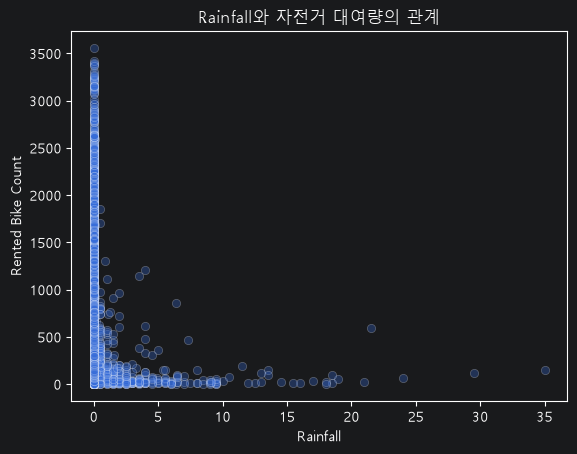

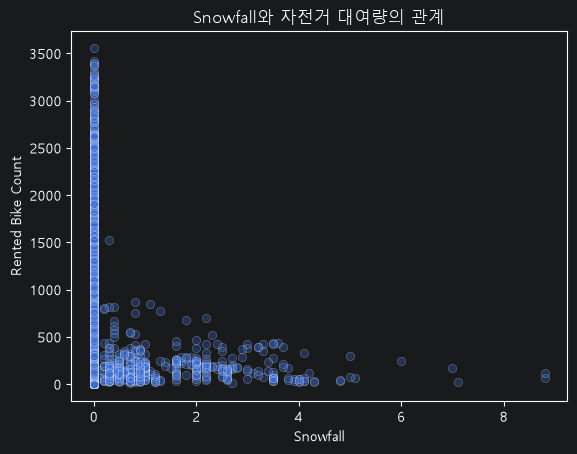

In [31]:
# 날씨 변수와 대여량 관계
weather_cols = ['Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Solar Radiation', 'Rainfall', 'Snowfall']

for col in weather_cols:
    sns.scatterplot(data=bike_df, x=col, y='Rented Bike Count', alpha=0.3)
    plt.title(f'{col}와 자전거 대여량의 관계')
    plt.show()

### 운영일 데이터만 사용

In [32]:
model_df = bike_df[bike_df['Functioning Day'] == 'Yes'].copy()
model_df = model_df.drop(columns=['Functioning Day'])
print('전체 데이터 크기: ', bike_df.shape)
print('운영일 데이터 크기: ', model_df.shape)

전체 데이터 크기:  (8760, 23)
운영일 데이터 크기:  (8465, 22)


### 학습 / 검증 데이터 분할
- 시간 기준 분할: 랜덤 분할은 미래 시점의 데이터가 학습 데이터에 섞일 수 있음. 수요 예측은 보통 과거를 보고 미래를 예측해야 하므로 시간 순서 기준 검증이 더 자연스러움

In [33]:
target = 'Rented Bike Count'
model_df = model_df.sort_values(['Date', 'Hour']).reset_index(drop=True)
feature_cols = [col for col in model_df.columns if col not in [target, 'Date']]

X = model_df[feature_cols]
y = model_df[target]

In [34]:
split_idx = int(len(model_df) * 0.8)
split_idx

6772

In [35]:
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print('학습 데이터: ', X_train.shape, y_train.shape)
print('테스트 데이터: ', X_test.shape, y_test.shape)
print('학습 기간: ', model_df.loc[:split_idx-1, 'Date'].min(), model_df.loc[:split_idx-1, 'Date'].max())
print('테스트 기간: ', model_df.loc[split_idx:, 'Date'].min(), model_df.loc[split_idx:, 'Date'].max())

학습 데이터:  (6772, 20) (6772,)
테스트 데이터:  (1693, 20) (1693,)
학습 기간:  2017-12-01 00:00:00 2018-09-11 00:00:00
테스트 기간:  2018-09-11 00:00:00 2018-11-30 00:00:00


### 전처리 파이프라인 구성

In [36]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
print('숫자형 변수: ', numeric_features)

숫자형 변수:  ['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


In [37]:
categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()
print('범주형 변수: ', categorical_features)

범주형 변수:  ['Seasons', 'Holiday']


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

### ※ 데이터 스케일링
데이터 스케일링은 서로 다른 범위와 단위를 가진 데이터를 일정한 범위로 변환하여 모델 학습을 더 효율적으로 수행할 수 있도록 만드는 전처리 과정입니다. 주로 변수 간의 값의 크기 차이가 클 때 발생하는 불균형을 해결하기 위해 사용되며, 대표적인 방법으로 표준화(Standardization)와 정규화(Normalization)가 있습니다. 스케일링을 통해 학습 속도를 높이고, 기울기 소실(Gradient Vanishing) 문제를 완화하며, 특정 변수에 모델이 과도하게 의존하는 것을 방지할 수 있습니다.

1. 표준화
    - 표준화(Standardization)는 데이터의 평균을 0으로, 표준편차를 1로 변환하여 모든 변수가 동일한 척도를 갖도록 만드는 데이터 전처리 기법입니다. 주로 데이터의 분포가 정규 분포를 따를 때 효과적이며, 값의 크기나 단위가 서로 다른 변수를 비교하거나 머신러닝 알고리즘(예: 로지스틱 회귀, SVM)에서 최적의 성능을 내기 위해 사용됩니다.

2. 정규화
    - 정규화(Normalization)는 데이터의 값을 특정 범위(주로 0과 1 사이)로 변환하여 변수 간의 스케일 차이를 줄이는 데이터 전처리 기법입니다. 이는 주로 최소값과 최대값을 사용해 데이터를 조정하며, 대표적인 방법으로 Min-Max Scaling이 있습니다.

In [39]:
numeric_tansformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_for_linear = ColumnTransformer(
    transformers = [
        ('num', numeric_tansformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 트리 계열 모델은 스케일링 필수가 아님
tree_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocess_for_tree = ColumnTransformer(
    transformers = [
        ('num', tree_numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### 평가 함수 만들기

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [41]:
def evaluate_regression(model, X_test, y_test, model_name):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return {
        'model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

In [42]:
def plot_actual_vs_pred(model, X_test, y_test, title):
    pred = model.predict(X_test)
    sns.scatterplot(x=y_test, y=pred, alpha=0.35)
    min_value = min(y_test.min(), pred.min())
    max_value = max(y_test.max(), pred.max())
    plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')
    plt.xlabel('실제값')
    plt.ylabel('예측값')
    plt.title(title)
    plt.show()

# **4. 기본 모델 비교**

### 1. DummyRegressor
- 아무것도 학습하지 않는 기준 모델
- 성능 좋은 모델을 만들기 위한 모델이라기보다는 다른 모델이 정말 학습을 잘하고 있는지 확인하기 위한 기준선
- 컬럼의 특징을 이용하지 않아 학습이 되지 않음

### 2. LinearRegression
- 입력값과 결과 사이에 직선 관계가 있다고 생각하는 모델
- 각 특성에 가중치를 부여하는 것
- 가장 큰 장점은 단순하고 해석하기 쉬움
- 어떤 변수가 결과에 양의 영향을 주는지, 음의 영향을 주는지를 비교적 쉽게 볼 수 있고 학습 속도도 빠름
- 문제는 현실 데이터가 항상 직선 관계가 아니라는 점 > 복잡한 비선형 관계에서는 트리 기반 모델보다 성능이 떨어질 수 있음

### 3. Ridge
- LinearRegression이 너무 과하게 학습하지 못하도록 제어한 모델
- LinearRegression + 규제(Regularization) > 가중치를 너무 극단적으로 생성하지 못하도록 함
- 같이 서로 강하게 관련된 변수가 함께 모델에 들어갈 대 선형회귀의 계수가 불안정해질 수 있음 > 극단적인 계수를 사용하지 않도록 학습
- 다중공선성 : 회귀 분석에서 독립 변수들(설명 변수) 간에 강한 상관관계가 존재하는 현상을 의미합니다. 이러한 상관관계가 높으면 각 독립 변수가 종속 변수에 미치는 개별적인 영향을 정확하게 추정하기 어려워지며, 회귀 계수의 추정치가 불안정해져 작은 데이터 변화에도 크게 변할 수 있습니다. 이는 모델의 예측 성능 저하와 해석의 신뢰성 감소로 이어질 수 있으므로, 다중공선성이 높은 변수를 식별하고 제거하거나 조정하는 것이 중요합니다.

### 4. DecisionTreeRegressor
- 질문을 계속 던지면서 데이터를 나누는 모델
- LinearRegression은 전체 데이터를 하나의 선형적인 관계로 설명하려고 하는 반면 DecisionTree는 각 조건에 따른 예측을 다르게 하는 방식
- 복잡한 비선형 관계를 학습할 수 있음
- 전처리 부담이 비교적 적고 특성 간의 복잡한 상호작용도 자동으로 학습할 수 있음
- 가장 큰 단점은 과적함 > 훈련을 과하게 진행하면 데이터를 거의 외워버릴 수 있음

### 5. RandomForestRegressor
- DecisionTree를 여러 개 만들어서 다수의 의견을 듣도록 함
- DecisionTree의 가장 큰 문제 중 하나가 불안정성(과적합). 데이터가 조금만 달라져도 만들어지는 트리 구조가 크게 달라질 수 있음
- DecisionTree 하나보다 일반적으로 훨씬 안정적이고 과적합 위험도 줄어듦
- 비선형 관계에도 강하고 특별한 튜닝 없이도 꽤 좋은 성능이 나오는 경우가 많음
- 학습과 예측에 더 많은 시간과 메모리가 필요

### 앙상블 모델
앙상블 모델(Ensemble Model)은 여러 개의 머신러닝 모델을 조합하여 하나의 강력한 예측 모델을 만드는 방법입니다. 각 개별 모델(약한 학습기, Weak Learner)이 가진 장점을 결합하고 약점을 보완함으로써 예측 정확도와 안정성을 향상시킵니다. 대표적인 앙상블 기법으로는 배깅(Bagging), 부스팅(Boosting), 스태킹(Stacking)이 있으며, 랜덤 포레스트(Random Forest)와 XGBoost는 각각 배깅과 부스팅을 대표하는 알고리즘입니다. 앙상블 모델은 특히 복잡한 문제나 다양한 패턴이 존재하는 데이터셋에서 뛰어난 성능을 발휘합니다.

### 6. GradientBoostingRegressor
- 앞의 트리가 틀린 부분을 다음 트리가 보완
- 약한 모델들을 순차적으로 연결하여 강한 모델을 만드는 방식
- 복잡한 비선형 관계를 학습할 수 있고 정형 데이터에서 높은 성능을 내는 경우가 많음
- RandomForest처럼 트리들을 독립적으로 만드는 방식이 아니라 앞 모델의 결과를 다음 모델에 이용하기 때문에 순차적인 특성이 강함
- 하이퍼파라미터에도 비교적 민감

### 7. HistGradientBoostingRegressor
- Gradient Boosting을 큰 데이터에서도 빠르게 처리하도록 개선
- 연속적인 값을 여러 개의 구간(bin)으로 묶어서 처리 > 많은 연속적인 값을 제한된 bin으로 변환하여 계산량을 줄임
- 데이터가 많을수록 일반적인 GradientBoostingRegressor 보다 학습 속도에서 이점을 얻을 수 있음



> RandomForest는 여러 트리의 의견을 평균내는 방식을 사용하고, GradientBoosting은 앞 모델의 실수를 다음 모델이 계속 보완하는 방식을 사용함

In [43]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

In [44]:
RANDOM_STATE = 2026

In [45]:
# alpha: alpha가 커질수록 규제가 강해짐. alpha가 작아지면 LinearRegression과 비슷 
models = {
    'Dummy': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', DummyRegressor(strategy='mean'))
    ]),
    'LinearRegression': Pipeline([
        ('preprocess', preprocess_for_linear),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('preprocess', preprocess_for_linear),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    'DecisionTree': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
    ]),
    'RandomForest': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300, n_jobs=-1))
    ]),
    'GradientBoosting': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]),
    'HistGradientBoosting': Pipeline([
        ('preprocess', preprocess_for_tree),
        ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ])
}

In [46]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    results.append(evaluate_regression(model, X_test, y_test, name))

In [47]:
result_df = pd.DataFrame(results).sort_values('RMSE')
result_df

,model,MAE,MSE,RMSE,R2
4,RandomForest,248.691815,116676.957001,341.580089,0.675170
6,HistGradientBoosting,263.682020,118478.338190,344.206825,0.670155
3,DecisionTree,280.760189,149756.217956,386.983485,0.583077
5,GradientBoosting,291.464397,154978.536430,393.673134,0.568538
0,Dummy,491.505685,402474.393763,634.408696,-0.120493
2,Ridge,593.567249,508831.061369,713.323953,-0.416591
1,LinearRegression,606.011756,527109.854457,726.023315,-0.467479


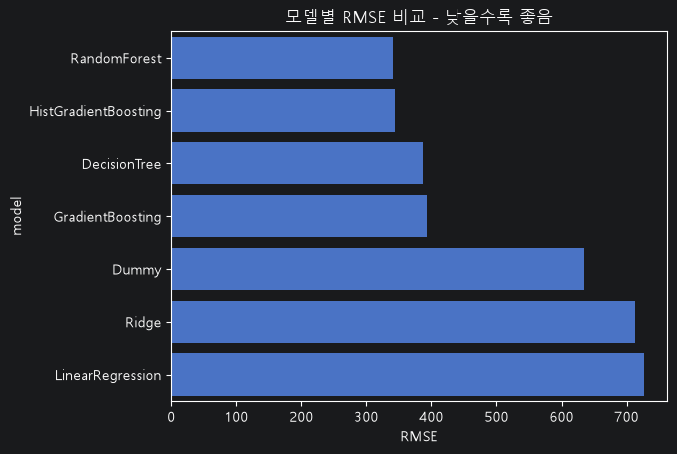

In [48]:
sns.barplot(data=result_df, x='RMSE', y='model')
plt.title('모델별 RMSE 비교 - 낮을수록 좋음')
plt.show()

# **5. Decision Tree**
Decision Tree는 데이터를 기반으로 의사결정을 수행하는 트리 구조의 예측 모델입니다. 루트 노드(root node)에서 시작해 각 노드는 특정 특성(feature)의 조건에 따라 가지(branch)로 분기되며, 최종적으로 리프 노드(leaf node)에 도달해 예측 결과(클래스나 값)를 도출합니다. 주로 분류(Classification)와 회귀(Regression) 문제에 사용되며, 데이터의 패턴을 직관적으로 시각화할 수 있어 해석이 용이합니다. 하지만 트리가 너무 깊어지면 과적합(overfitting) 문제가 발생할 수 있으므로 가지치기(pruning)나 최대 깊이 설정 등으로 제어해야 합니다.

### 1. Decision Tree의 학습 순서

```
1. 전체 데이터셋을 하나의 노드로 시작합니다.
2. 최적의 특성(feature)과 분할 기준(threshold)을 찾아 첫 번째 분할을 수행합니다.
    분류 (Classification):
        Gini 불순도(Gini Impurity)
        엔트로피(Entropy)
    회귀 (Regression):
        평균 제곱 오차(Mean Squared Error, MSE)
        절대 평균 오차(Mean Absolute Error, MAE)
3. 각 하위 노드에 대해 위 단계를 반복합니다.
4. 이 과정을 통해 트리는 여러 깊이로 성장합니다.
5. 모든 노드가 더 이상 나눌 수 없거나 특정 조건(max_depth, min_samples_split)을 만족할 때까지 반복됩니다.
6. 더 이상 분할이 불가능할 때 리프 노드가 생성됩니다.
    분류 문제: 가장 많은 클래스가 있는 클래스를 예측값으로 사용
    회귀 문제: 평균값을 예측값으로 사용
```


### ※ Gini 불순도 (Gini Impurity)
- Gini 불순도는 한 노드에 있는 데이터의 순수도(Purity)를 측정하는 지표입니다.
- 한 노드에 있는 샘플들이 동일한 클래스에 속할 확률이 높을수록 Gini 불순도는 낮아집니다.
>즉, 노드가 "얼마나 섞여 있는지"를 나타냅니다.

### ※ 엔트로피 (Entropy)
- 엔트로피는 정보의 불확실성(혼란도, Uncertainty)을 측정합니다.
- 엔트로피가 높을수록 해당 노드에 있는 데이터는 더 섞여 있으며, 예측하기 어렵습니다.
- 엔트로피는 데이터가 균등하게 분포될 때 최대값을 가집니다.

### ※ DecisionTreeRegressor 계산 예
DecisionTreeRegressor는 주어진 데이터를 반복적으로 분할하여 예측을 수행합니다. 각 분할은 데이터의 목표 변수 값을 예측하는 데 가장 적합한 값을 찾기 위해 이루어집니다. 이를 통해 데이터를 점차 더 작은 부분으로 나누고, 각 부분에서 평균값을 예측값으로 사용하는 방식입니다. DecisionTreeRegressor 데이터를 두 가지 그룹으로 분할합니다. 각 분할에서 목표는 두 그룹의 MSE가 가능한 한 낮도록 만드는 것입니다. 즉, 각 분할에서의 MSE가 최소화되도록 분할점을 찾습니다.

![결정트리 예](./images/결정트리예.png)

![분산 계산](./images/분산계산.png)

![분산 계산](./images/분산계산2.png)

### DecisionTreeRegressor의 하이퍼파리미터 튜닝
DecisionTree는 아무 제한 없이 학습하면 과적합되기 쉬움

- max_depth: 트리의 최대 깊이
- min_samples_split: 노드를 나누기 위한 최소 샘플 수
- min_samples_leaf: 리프 노드에 있어야 하는 최소 샘플 수

In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
dt_pipepline = Pipeline([
    ('preprocess', preprocess_for_tree),
    ('model', DecisionTreeRegressor(random_state=2026))
])

param_grid = {
    'model__max_depth': [10, 15, 20, 25],
    'model__min_samples_split': [10, 30, 50, 70],
    'model__min_samples_leaf': [5, 10, 20, 50]
}

# scoring='neg_root_mean_squared_error'
# GridSearchCV가 점수가 클수록 좋은 모델이라는 규칙으로 동작
# RMSE는 작을수록 좋은 모델
# scikit-learn이 RMSE에 마이너스를 붙여서 GridSearchCV가 비교할 수 있도록 만든 것
dt_grid = GridSearchCV(estimator=dt_pipepline, 
                       param_grid=param_grid, 
                       scoring='neg_root_mean_squared_error', 
                       cv=3, n_jobs=-1)

In [51]:
dt_grid.fit(X_train, y_train);

In [52]:
print('Best Params: ', dt_grid.best_params_)
print('Best CV RMSE: ', -dt_grid.best_score_) # scoring이 negative RMSE였기 때문에 음수 부호 제거

Best Params:  {'model__max_depth': 15, 'model__min_samples_leaf': 5, 'model__min_samples_split': 70}
Best CV RMSE:  387.63023366151464


In [53]:
tuned_dt_result = evaluate_regression(dt_grid.best_estimator_, X_test, y_test, 'DecisionTree_Tuned')
tuned_dt_result

{'model': 'DecisionTree_Tuned',
 'MAE': 318.5125883647883,
 'MSE': 192031.8761942807,
 'RMSE': 438.21441805842113,
 'R2': 0.4653813383606856}

In [54]:
final_result_df = pd.concat([result_df, pd.DataFrame([tuned_dt_result])], ignore_index=True)
final_result_df = final_result_df.sort_values('RMSE').reset_index(drop=True)
final_result_df

,model,MAE,MSE,RMSE,R2
0,RandomForest,248.691815,116676.957001,341.580089,0.675170
1,HistGradientBoosting,263.682020,118478.338190,344.206825,0.670155
2,DecisionTree,280.760189,149756.217956,386.983485,0.583077
3,GradientBoosting,291.464397,154978.536430,393.673134,0.568538
4,DecisionTree_Tuned,318.512588,192031.876194,438.214418,0.465381
5,Dummy,491.505685,402474.393763,634.408696,-0.120493
6,Ridge,593.567249,508831.061369,713.323953,-0.416591
7,LinearRegression,606.011756,527109.854457,726.023315,-0.467479


In [55]:
best_model_name = final_result_df.iloc[0]['model']
print("가장 RMSE가 낮은 모델:", best_model_name)

가장 RMSE가 낮은 모델: RandomForest


In [57]:
if best_model_name == 'DecisionTree_Tuned':
    best_model = dt_grid.best_estimator_
else:
    best_model = models[best_model_name]

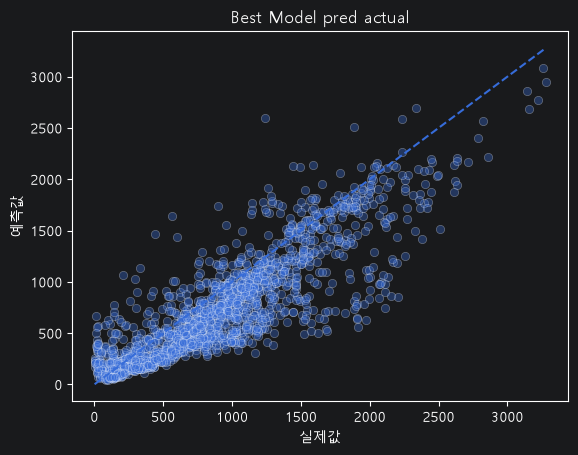

In [58]:
plot_actual_vs_pred(best_model, X_test, y_test, "Best Model pred actual")

In [62]:
# 테스트기간의 실제 값과 실제값곽 예측값을 시간 순서로 비교
pred = best_model.predict(X_test)
compare_df = model_df.iloc[split_idx:].copy()
compare_df['prediction'] = pred
compare_df[['Rented Bike Count', 'prediction']]

,Rented Bike Count,prediction
6772,193,208.836667
6773,258,239.390000
6774,678,635.240000
6775,1556,1253.010000
6776,2369,1722.436667
...,...,...
8460,1003,528.226667
8461,764,450.096667
8462,694,411.050000
8463,712,383.536667


In [63]:
sample_compare = compare_df.head(24 * 14) # 테스트 기간 앞에서 2주 가량

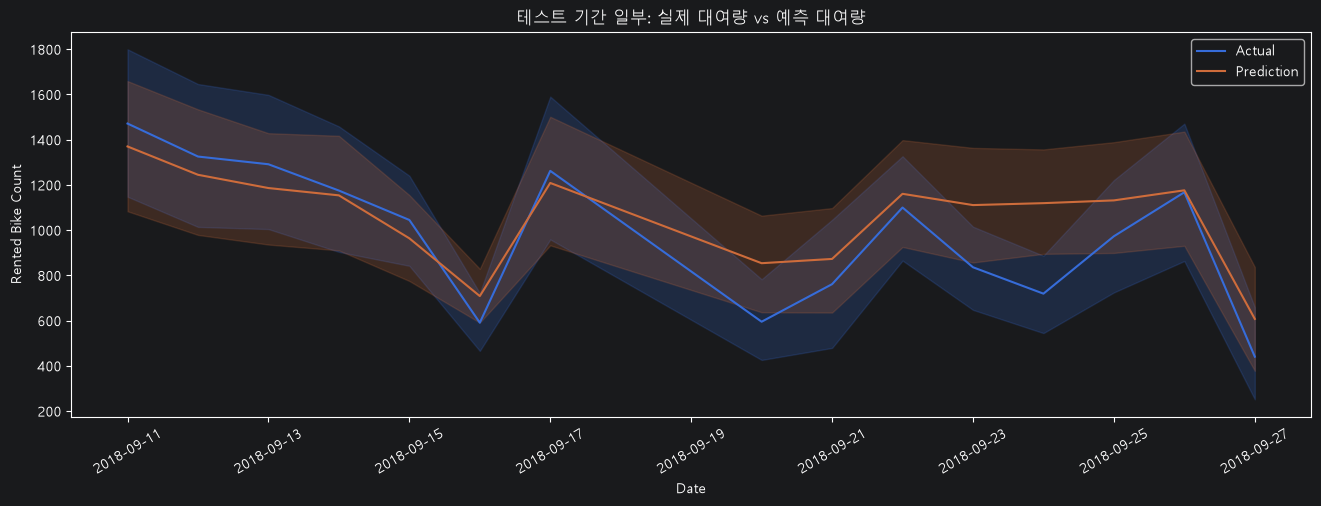

In [64]:
plt.figure(figsize=(16, 5))
sns.lineplot(data=sample_compare, x='Date', y='Rented Bike Count', label='Actual')
sns.lineplot(data=sample_compare, x='Date', y='prediction', label='Prediction')
plt.title('테스트 기간 일부: 실제 대여량 vs 예측 대여량')
plt.xticks(rotation=30)
plt.show()

 # **6. 피처 중요도 확인**
- 트리 계열 모델에서는 피처 중요도를 확인할 수 있음
- 피처 중요도는 인과관계를 의미하지 않음
- `One-Hot Encoding` 범주형 변수는 여러개의 컬럼으로 나누어 표시됨
- 상관관계가 강한 변수끼리는 중요도가 나뉘거나 한쪽으로 몰릴 수 있음

In [66]:
# preprocessor: ColumnTransformer로 전처리 한 뒤, 최종적으로 만들어진 컬럼이름들을 다시 얻어오는 함수
# OneHotEncoder을 사용하면 컬럼 하나가 여러 컬럼으로 늘어나기 때문에, 모델의 feature importance등을 확인할 때 유용하다
"""
preprocess_for_tree = ColumnTransformer(
    transformers = [
        ('num', tree_numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
"""
# RandomForest 등의 feature_importances_ = 피처 중요도 를 출력하려면 각 중요도가 어떤 컬럼에 해당하는지 알아야함
def get_feature_names(preprocessor):
    names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue
        if hasattr(transformer, 'named_steps') and 'onehot' in transformer.named_steps:
            onehot = transformer.named_steps['onehot']
            names.extend(onehot.get_feature_names_out(cols))
        else:
            names.extend(cols)
    return np.array(names)

In [67]:
# scikit-learn에서 학습을 통해 만들어진 것
# transformers_: Transformer 정보를 가지고있음
# feature_importances_: 피처 중요도
# coef_: 가중치 / 기울기 / 계수
# intercept_: 절편 / 편향
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    feature_names = get_feature_names(best_model.named_steps['preprocess'])

    importances = best_model.named_steps['model'].feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names, 'importance': importances
    }).sort_values("importance", ascending=False)

importance_df

,feature,importance
1,Temperature,0.388665
0,Hour,0.230022
6,Solar Radiation,0.079049
2,Humidity,0.058650
7,Rainfall,0.056478
14,hour_sin,0.043055
15,hour_cos,0.024583
5,Dew point temperature,0.023142
12,dayofweek,0.019605
17,month_cos,0.018028


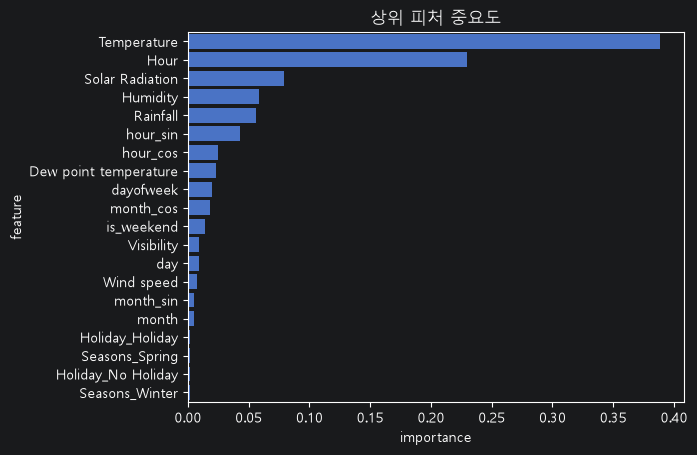

In [68]:
sns.barplot(data=importance_df.head(20), x='importance', y='feature')
plt.title('상위 피처 중요도')
plt.show()

In [71]:
tree_model = dt_grid.best_estimator_.named_steps['model']
feature_names = get_feature_names(dt_grid.best_estimator_.named_steps['preprocess'])
feature_names

array(['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility',
       'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall',
       'year', 'month', 'day', 'dayofweek', 'is_weekend', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'Seasons_Autumn',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_Holiday', 'Holiday_No Holiday'], dtype='<U21')

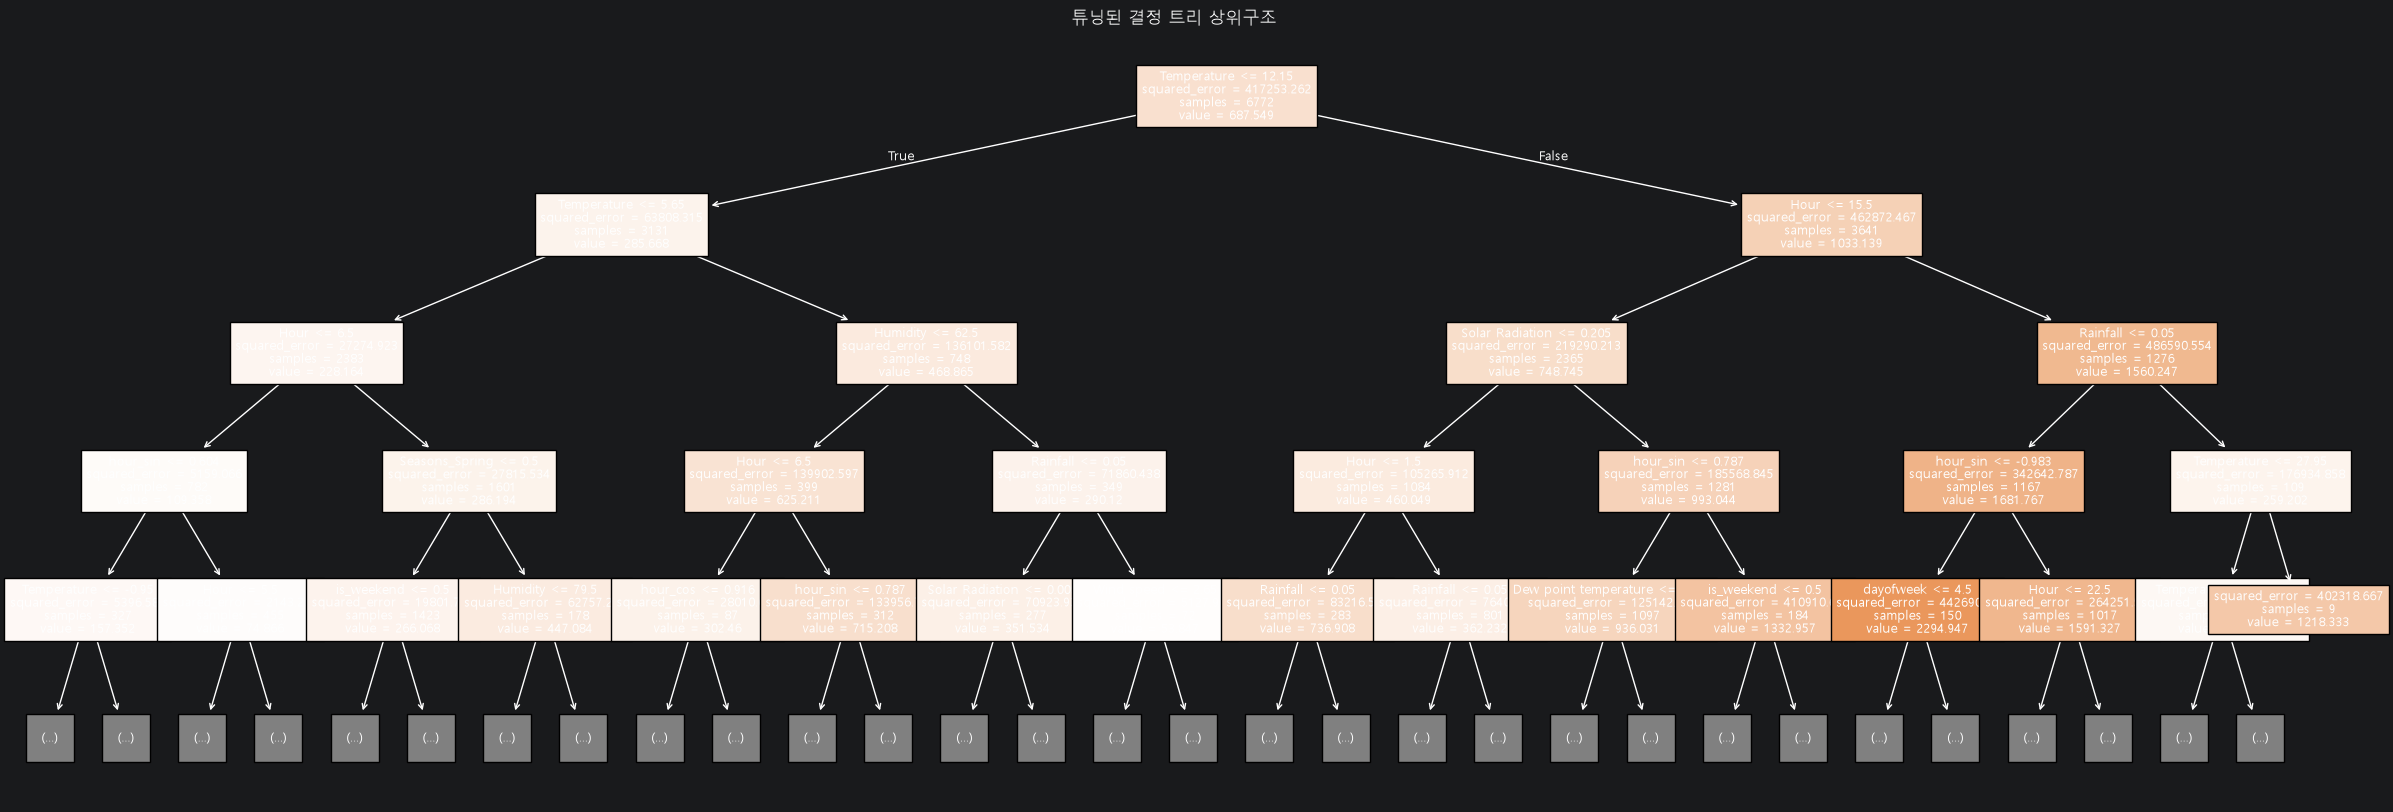

In [74]:
plt.figure(figsize=(30, 10))
plot_tree(tree_model, max_depth=4, feature_names=feature_names, filled=True, fontsize=9)
# filled: 값에 따라 색이 달라짐. 회귀 문제에서는 노드의 예측 값에 따라 색의
# 진하기 등이 달라져서 값이 상태적으로 큰 영역과 작은 영역으로 시각적으로 구분하기 쉬움
plt.title("튜닝된 결정 트리 상위구조")
plt.show()